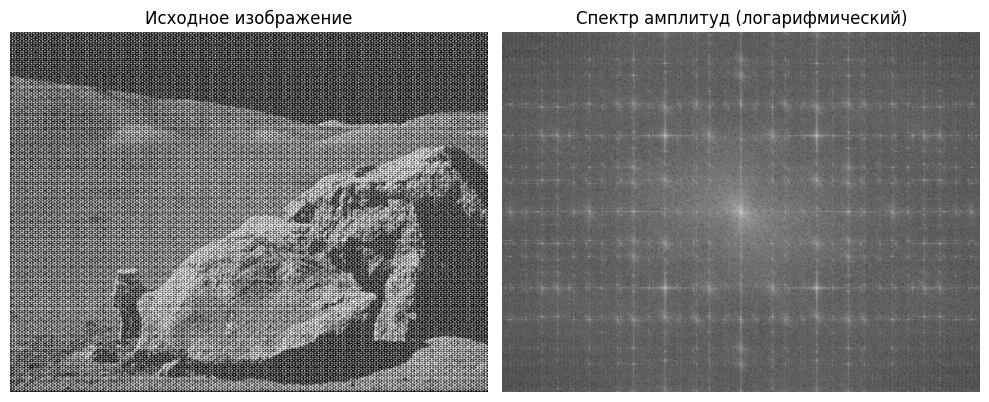

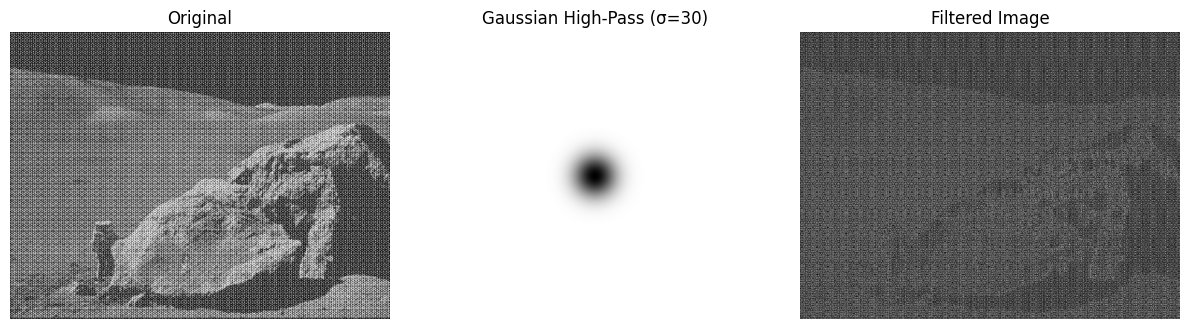

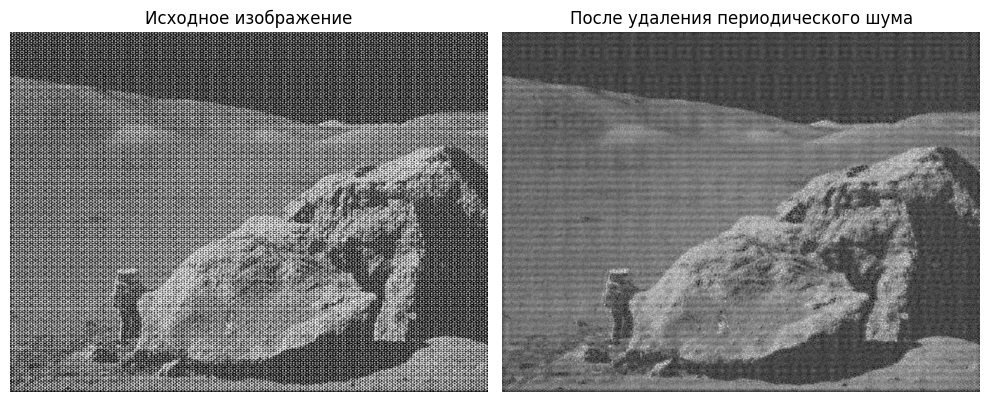

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt


def apply_dft(image):
    dft = cv.dft(np.float32(image), flags=cv.DFT_COMPLEX_OUTPUT)
    return np.fft.fftshift(dft)


def magnitude_spectrum_from_dft(dft_shift):
    # Вычисляем логарифмический спектр амплитуд для визуализации
    magnitude = cv.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
    return 20 * np.log(magnitude + 1e-8)  # добавляем маленькое число, чтобы избежать log(0)


def apply_inverse_dft(dft_shift):
    dft_unshifted = np.fft.ifftshift(dft_shift)
    image_back = cv.idft(dft_unshifted)
    return cv.magnitude(image_back[:, :, 0], image_back[:, :, 1])


def create_gaussian_filter(shape, sigma, high_pass=True):
    # Создаём гауссов фильтр: высокочастотный или низкочастотный
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    gaussian = np.exp(-((x - center_col)**2 + (y - center_row)**2) / (2 * sigma**2))
    return 1 - gaussian if high_pass else gaussian


def remove_periodic_noise(image, log_magnitude, percentile=96, center_radius_ratio=0.1):
    dft = cv.dft(np.float32(image), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    threshold = np.percentile(log_magnitude, percentile)
    noise_mask = log_magnitude > threshold

    rows, cols = image.shape
    center_y, center_x = rows // 2, cols // 2
    center_radius = int(min(rows, cols) * center_radius_ratio)

    # Создаём маску для комплексного спектра
    filter_mask = np.ones((rows, cols, 2), dtype=np.float32)

    # Проходим по всем пикселям частотного спектра
    for y in range(rows):
        for x in range(cols):
            if noise_mask[y, x]:
                dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                if dist_from_center > center_radius:
                    filter_mask[y, x] = 0
                    filter_mask[rows - 1 - y, cols - 1 - x] = 0

    # Применяем маску к спектру и выполняем обратное преобразование
    filtered_dft_shift = dft_shift * filter_mask
    reconstructed = apply_inverse_dft(filtered_dft_shift)

    # Нормализуем результат к диапазону [0, 255] для корректного отображения
    denoised = cv.normalize(reconstructed, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    return denoised


# Загружаем изображение в оттенках серого
image = cv.imread("periodic_noise.jpg", cv.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Изображение 'periodic_noise.jpg' не найдено!")


dft_shift = apply_dft(image)
log_magnitude = magnitude_spectrum_from_dft(dft_shift)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(122)
plt.imshow(log_magnitude, cmap='gray')
plt.title('Спектр амплитуд (логарифмический)')
plt.axis('off')
plt.tight_layout()
plt.show()


sigma = 30
gaussian_hp = create_gaussian_filter(image.shape, sigma, high_pass=True)
filtered_dft = dft_shift * gaussian_hp[:, :, np.newaxis]
filtered_image = apply_inverse_dft(filtered_dft)

results_gauss = {
    "Original": image,
    f"Gaussian High-Pass (σ={sigma})": gaussian_hp,
    "Filtered Image": filtered_image,
}

plt.figure(figsize=(12, 4))
for i, (title, img) in enumerate(results_gauss.items()):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


denoised_image = remove_periodic_noise(
    image,
    log_magnitude,
    percentile=96,
    center_radius_ratio=0.1
)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(122)
plt.imshow(denoised_image, cmap='gray')
plt.title('После удаления периодического шума')
plt.axis('off')
plt.tight_layout()
plt.show()